# **Customer Churn Prediction – Telco Dataset**

## Business Problem

Subscription businesses lose a lot of money when customers cancel (churn).  
Acquiring new customers is usually more expensive than keeping existing ones, so it is critical to identify customers who are at risk of leaving and take action before they churn.

## Objective

Build a machine learning model that predicts which customers are likely to churn using their:
- Demographic information
- Service usage
- Contract and billing details

We will use this model to understand key churn drivers and to help design targeted retention strategies.

## How the model can be used

- Identify high‑risk customers each month and trigger retention campaigns (calls, emails, special offers).
- Prioritize discounts or loyalty programs for customers with the highest predicted churn risk.
- Support business decisions about contract types, internet services, and add‑on products.

## Dataset

Dataset: **Telco Customer Churn (IBM sample dataset)** – 7043 customers and 21 columns, with “Churn” as the target. Each row is a customer, and each column is an attribute such as tenure, contract type, and monthly charges.  
Source: IBM Telco Customer Churn sample / Kaggle “Telco Customer Churn”.

## Import Libraries

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

## Load and inspect data

In [4]:
df = pd.read_csv('Telco_Customer_Churn.csv')

In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data cleaning and preparation

Key steps:
- Convert `TotalCharges` to numeric and handle 11 invalid/missing values.
- Drop `customerID` because it is just an identifier.
- Encode `Churn` as 0/1.

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],
                                   errors="coerce")

In [11]:
df['TotalCharges'].dtype

dtype('float64')

In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
df.dropna(inplace= True)

In [35]:
df.shape # 11 records removed

(7032, 21)

In [14]:
df = df.drop(columns=["customerID"])

In [15]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [16]:
df.shape

(7032, 20)

In [17]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


## Exploratory data analysis

We explore:
- Target distribution (churn vs non-churn).
- Relationship between churn and key features like tenure and contract.

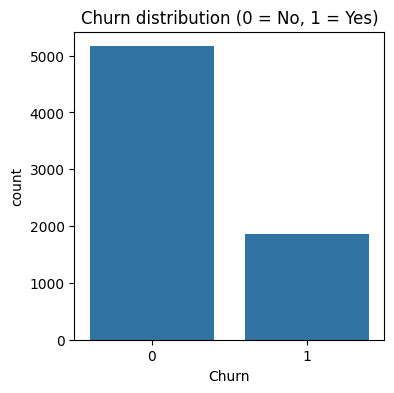

In [18]:
plt.figure(figsize=(4,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn distribution (0 = No, 1 = Yes)")
plt.show()

The dataset contains more non-churn customers than churn customers, indicating a class imbalance in the target variable.

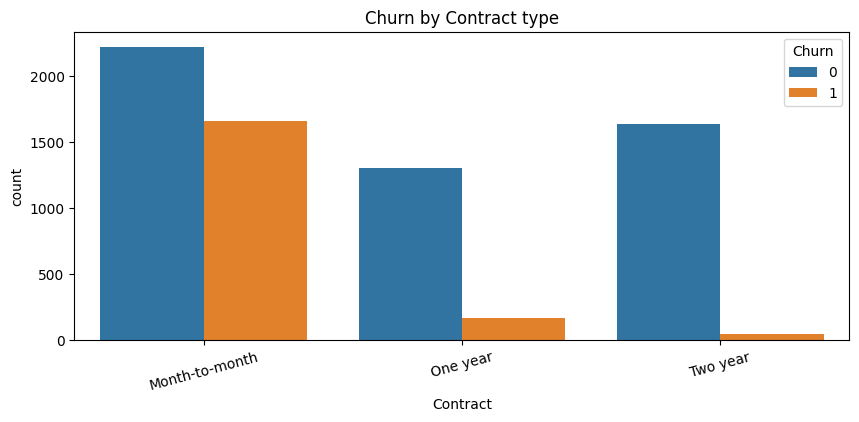

In [19]:
plt.figure(figsize=(10,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract type")
plt.xticks(rotation=15)
plt.show()

Customers with month-to-month contracts have the highest churn rate compared to customers with one-year and two-year contracts.

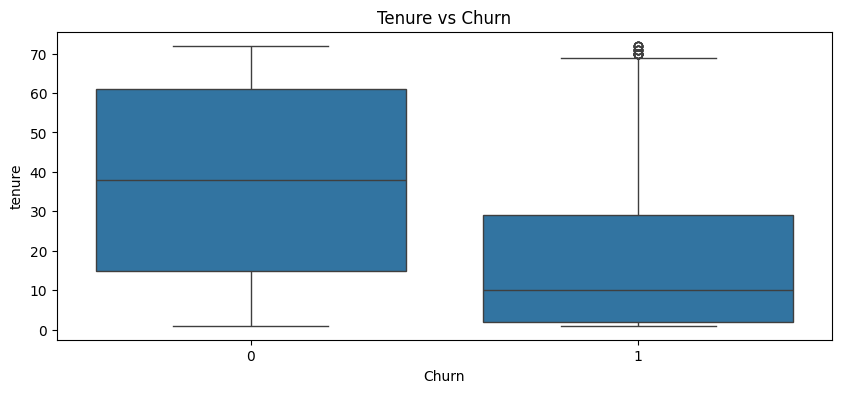

In [20]:
plt.figure(figsize=(10,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

Customers with shorter tenure are more likely to discontinue the service

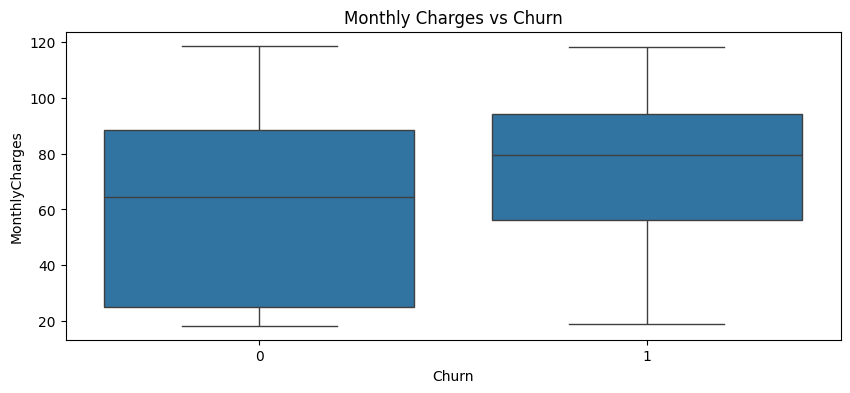

In [21]:
plt.figure(figsize=(10,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges show higher churn rates in this dataset.

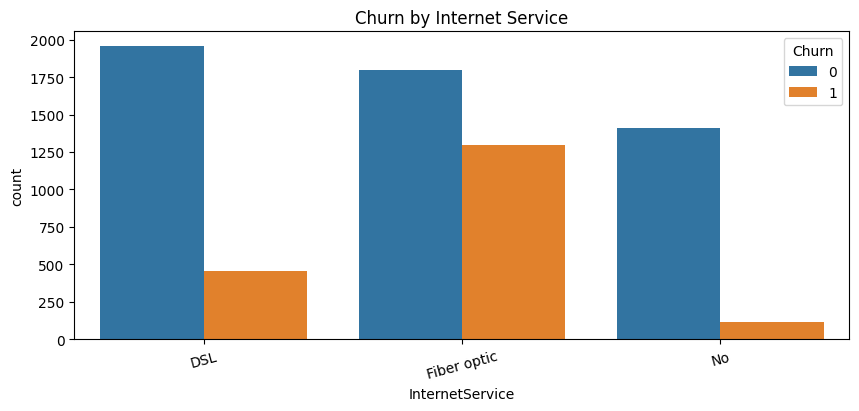

In [22]:
plt.figure(figsize=(10,4))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service")
plt.xticks(rotation=15)
plt.show()

Customers using Fiber optic internet service show a higher tendency to churn compared to DSL and customers without internet service.

## Feature engineering

We engineer a simple feature:
- `TotalServices`: number of subscribed services (phone, internet, streaming), as a rough measure of engagement.

In [23]:
service_cols = [
    "PhoneService",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = 0

for col in service_cols:
    df["TotalServices"] += df[col].apply(
        lambda x: 0 if x in ["No", "No internet service"] else 1
    )

In [24]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices'],
      dtype='object')

## Train–test split and preprocessing

We:
- Split data into train and test sets.
- Define numeric and categorical columns.
- Build a preprocessing pipeline:
  - Numeric: median imputation + standardization.
  - Categorical: most-frequent imputation + one-hot encoding.

In [25]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 42,
    stratify= y)

In [26]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "TotalServices"]

cat_cols = [col for col in X.columns if col not in num_cols]

In [27]:
num_tran = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

cat_tran = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [28]:
preprocessor = ColumnTransformer(transformers= [
    ('num', num_tran, num_cols),
    ('cat', cat_tran, cat_cols)
])

## Model 1 – Logistic Regression

We start with Logistic Regression:
- Simple and interpretable.
- Baseline model to compare against more complex models.

In [29]:
model_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter= 500,
                                      class_weight="balanced"))
])

model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)
print(accuracy_score(y_test, y_pred_1))
print(classification_report(y_test, y_pred_1))

0.7263681592039801
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



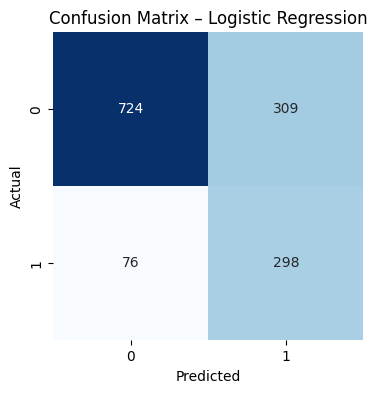

In [30]:
cm_lr = confusion_matrix(y_test, y_pred_1)
plt.figure(figsize=(4,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

## Model 2 – Random Forest

We train a Random Forest classifier:
- Can capture non-linear relationships and interactions.
- Often achieves higher accuracy but is less interpretable than Logistic Regression.

In [37]:
model_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators= 100,
                                          random_state= 42))
])

model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
print(accuracy_score(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))

0.7867803837953091
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



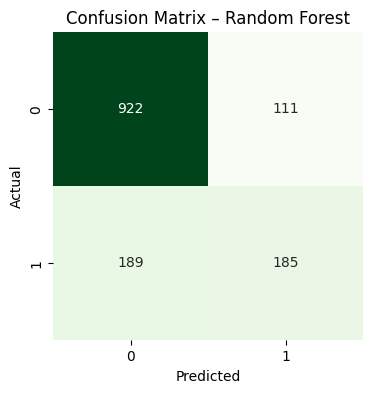

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(4,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()

## 8. Model comparison

We compare Logistic Regression and Random Forest on:
- Accuracy
- Precision, recall, and F1 for the churn (positive) class.

## Model Comparison

| Model | Accuracy | Precision (Churn = 1) | Recall (Churn = 1) | F1 Score (Churn = 1) |
|------|----------:|----------------------:|-------------------:|---------------------:|
| Logistic Regression | 0.73 | 0.49 | 0.80 | 0.61 |
| Random Forest | 0.79 | 0.62 | 0.49 | 0.55 |

Random Forest gives higher overall accuracy, but Logistic Regression performs better at identifying churners because it has much higher recall for the positive class.

## Feature Importance

The coefficients of Logistic Regression were analyzed to understand which features influence customer churn prediction.

In [33]:
coefficients = model_1.named_steps["classifier"].coef_[0]
feature_names = model_1.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

/tmp/ipykernel_699/950831150.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x="Coefficient", y="Feature", palette="viridis")


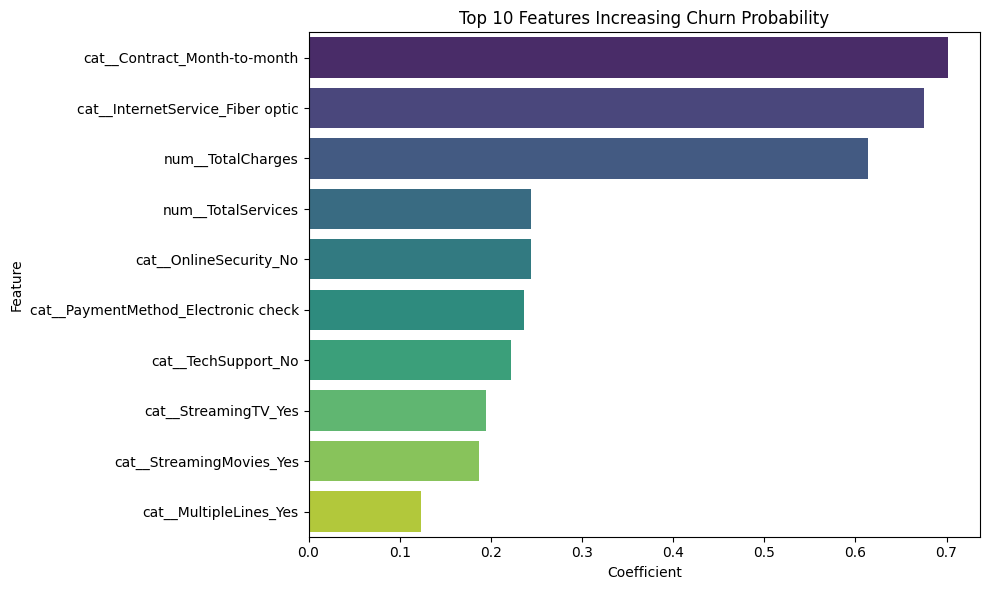

In [34]:
top_10 = feature_importance.sort_values(by="Coefficient", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x="Coefficient", y="Feature", palette="viridis")
plt.title("Top 10 Features Increasing Churn Probability")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Conclusions and Business Insights

- The dataset is moderately imbalanced, with around 26–27% of customers experiencing churn.
- Logistic Regression provided an interpretable baseline, while Random Forest achieved better overall performance with less interpretability.
- Key churn drivers identified from model coefficients include:
  - Month-to-month contracts
  - Fiber optic internet service
  - Lack of online security, backup, and tech support services
  - Electronic check payment method
- Customer charges and service usage patterns indicate that pricing strategy and service bundles may influence churn behavior.

### Business Recommendations

- Focus retention efforts on high-risk segments, especially month-to-month fiber optic customers.
- Promote security, backup, and support service bundles to improve customer retention.
- Monitor electronic check customers as a higher-risk group.
- Use the trained model for regular churn-risk scoring to prioritize customer outreach.